In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

path = "../data/Walmart.csv"
df = pd.read_csv(path)

In [2]:
path = "../data/Walmart.csv"
df = pd.read_csv(path)
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.to_period('M')

print(f"Shape: {df.shape}")
print(f"Stores: {df['Store'].nunique()}, Weeks per store: {df.groupby('Store').size().unique()}")
print(f"Date range: {df['Date'].min().date()} -> {df['Date'].max().date()}")
df.head()

Shape: (6435, 10)
Stores: 45, Weeks per store: [143]
Date range: 2010-02-05 -> 2012-10-26


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month
0,1,2010-02-05,"1,643,690.90",0,42.31,2.57,211.10,8.11,2010,2010-02
1,1,2010-02-12,"1,641,957.44",1,38.51,2.55,211.24,8.11,2010,2010-02
2,1,2010-02-19,"1,611,968.17",0,39.93,2.51,211.29,8.11,2010,2010-02
3,1,2010-02-26,"1,409,727.59",0,46.63,2.56,211.32,8.11,2010,2010-02
4,1,2010-03-05,"1,554,806.68",0,46.50,2.62,211.35,8.11,2010,2010-03


In [3]:
store_stats = df.groupby('Store')['Weekly_Sales'].agg(Total='sum', Avg='mean', Std='std')
store_stats = store_stats.sort_values('Total', ascending=False)
store_stats['Rank'] = range(1, len(store_stats) + 1)
n = len(store_stats)
def tier(rank):
    if rank <= 10: return 'Top 10'
    if rank > n - 10: return 'Bottom 10'
    return 'Mid 25'
store_stats['Tier'] = store_stats['Rank'].apply(tier)
print(store_stats['Tier'].value_counts())
store_stats.head(10)

Tier
Mid 25       25
Top 10       10
Bottom 10    10
Name: count, dtype: int64


,Total,Avg,Std,Rank,Tier
Store,,,,,
20,"301,397,792.46","2,107,676.87","275,900.56",1,Top 10
4,"299,543,953.38","2,094,712.96","266,201.44",2,Top 10
14,"288,999,911.34","2,020,978.40","317,569.95",3,Top 10
13,"286,517,703.80","2,003,620.31","265,507.00",4,Top 10
2,"275,382,440.98","1,925,751.34","237,683.69",5,Top 10
10,"271,617,713.89","1,899,424.57","302,262.06",6,Top 10
27,"253,855,916.88","1,775,216.20","239,930.14",7,Top 10
6,"223,756,130.64","1,564,728.19","212,525.86",8,Top 10
1,"222,402,808.85","1,555,264.40","155,980.77",9,Top 10


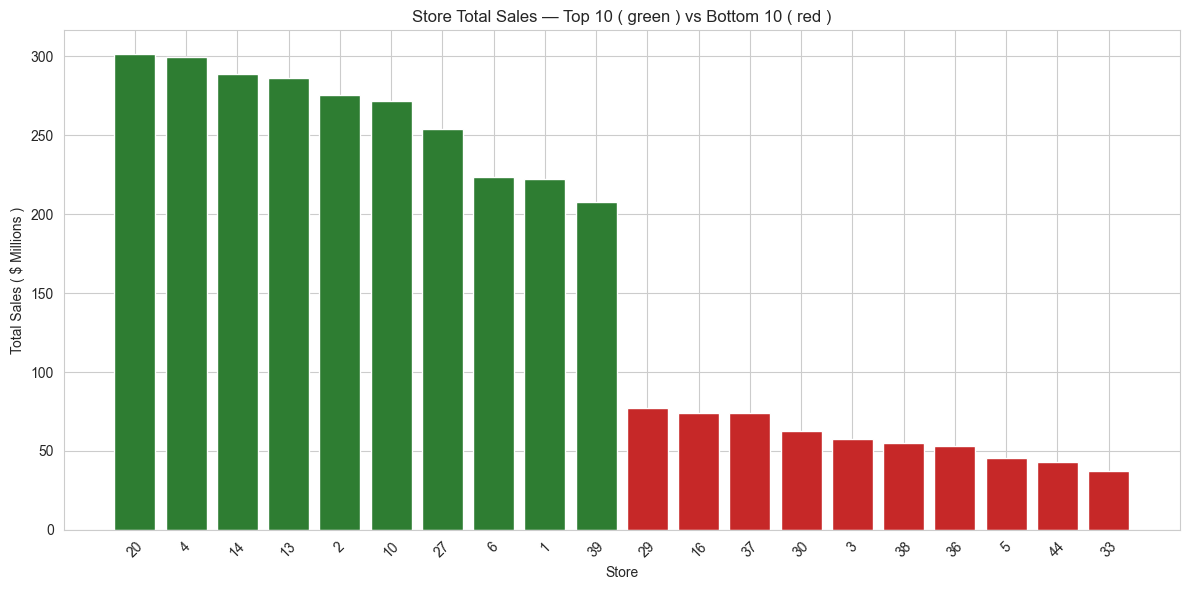

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
top10 = store_stats.head(10)
bottom10 = store_stats.tail(10)
plot_df = pd.concat([top10, bottom10])
colors = ['#2e7d32'] * 10 + ['#c62828'] * 10
ax.bar(plot_df.index.astype(str), plot_df['Total'] / 1e6, color=colors)
ax.set_xlabel('Store')
ax.set_ylabel('Total Sales ( $ Millions )')
ax.set_title('Store Total Sales — Top 10 ( green ) vs Bottom 10 ( red )')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('store_ranking.png', dpi=150)
plt.show()

In [5]:
hol_avg = df[df['Holiday_Flag'] == 1]['Weekly_Sales'].mean()
normal_avg = df[df['Holiday_Flag'] == 0]['Weekly_Sales'].mean()
uplift_overall = (hol_avg / normal_avg - 1) * 100
print(f"Holiday week avg: ${hol_avg:,.0f}")
print(f"Normal week avg:  ${normal_avg:,.0f}")
print(f"Overall uplift:   {uplift_overall:+.2f}%")
hol_dates = sorted(df[df['Holiday_Flag'] == 1]['Date'].unique())
def label_holiday(ts):
    ts = pd.Timestamp(ts)
    m = ts.month
    return {2: 'Super Bowl', 9: 'Labor Day', 11: 'Thanksgiving', 12: 'Christmas'}.get(m)
df['HolidayName'] = df['Date'].map(lambda d: label_holiday(d) if d in hol_dates else None)
holiday_summary = df[df['Holiday_Flag'] == 1].groupby('HolidayName')['Weekly_Sales'].mean().to_frame('AvgSales')
holiday_summary['Uplift_%'] = (holiday_summary['AvgSales'] / normal_avg - 1) * 100
holiday_summary = holiday_summary.sort_values('Uplift_%', ascending=False)
holiday_summary

Holiday week avg: $1,122,888
Normal week avg:  $1,041,256
Overall uplift:   +7.84%


,AvgSales,Uplift_%
HolidayName,,
Thanksgiving,"1,471,273.43",41.30
Super Bowl,"1,079,127.99",3.64
Labor Day,"1,042,427.29",0.11
Christmas,"960,833.11",-7.72


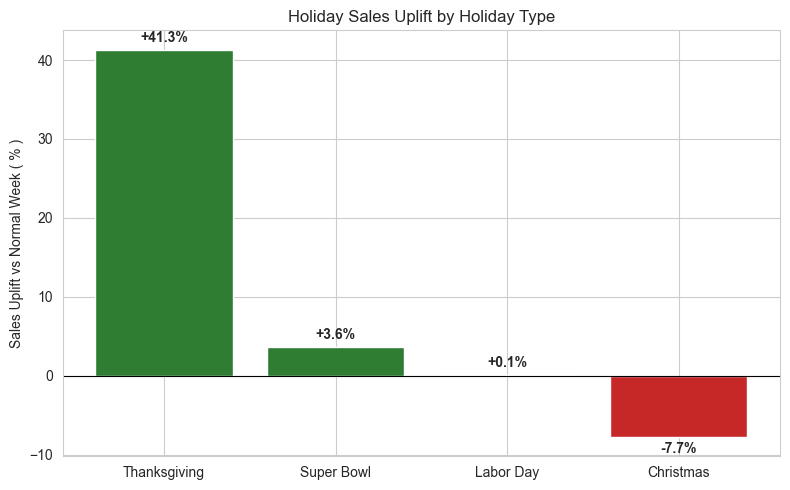

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
colors2 = ['#2e7d32' if v >= 0 else '#c62828' for v in holiday_summary['Uplift_%']]
ax.bar(holiday_summary.index, holiday_summary['Uplift_%'], color=colors2)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Sales Uplift vs Normal Week ( % )')
ax.set_title('Holiday Sales Uplift by Holiday Type')
for i, v in enumerate(holiday_summary['Uplift_%']):
    ax.text(i, v + (1 if v >= 0 else -2), f'{v:+.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('holiday_uplift.png', dpi=150)
plt.show()

Peak month: 2010-12 ($288,760,533)


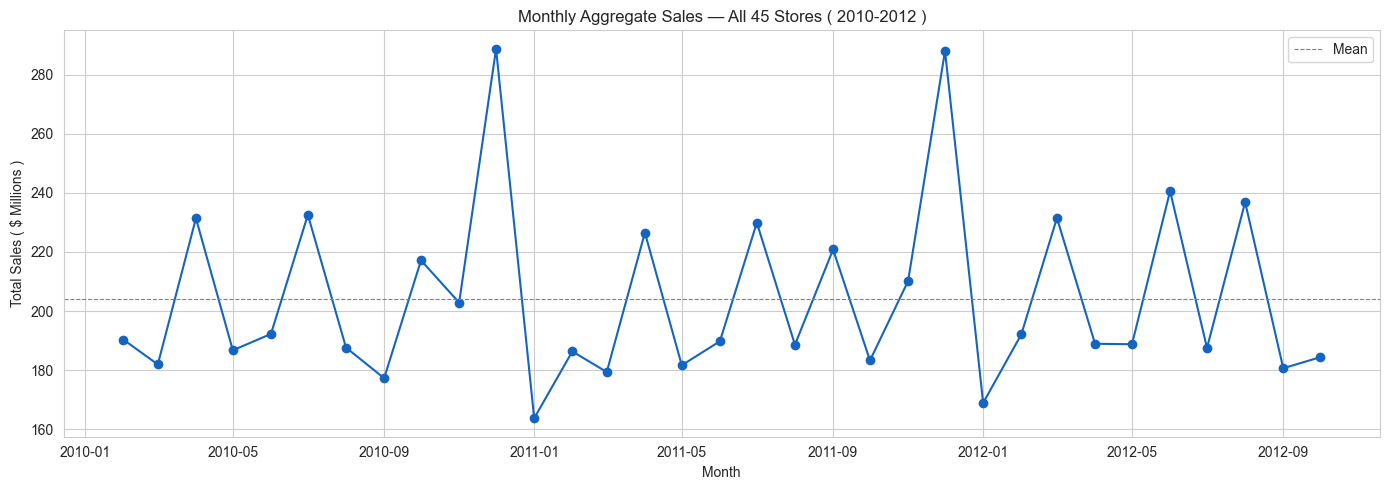

In [7]:
monthly = df.groupby('Month')['Weekly_Sales'].sum()
print(f"Peak month: {monthly.idxmax()} (${monthly.max():,.0f})")
fig, ax = plt.subplots(figsize=(14, 5))
monthly.index = monthly.index.to_timestamp()
ax.plot(monthly.index, monthly.values / 1e6, marker='o', color='#1565c0')
ax.set_ylabel('Total Sales ( $ Millions )')
ax.set_xlabel('Month')
ax.set_title('Monthly Aggregate Sales — All 45 Stores ( 2010-2012 )')
ax.axhline(monthly.mean() / 1e6, color='gray', linestyle='--', linewidth=0.8, label='Mean')
ax.legend()
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150)
plt.show()

In [8]:
pivot = df.pivot_table(index='Store', columns='Year', values='Weekly_Sales', aggfunc='sum')
pivot['YoY_2011_%'] = (pivot[2011] / pivot[2010] - 1) * 100
pivot['YoY_2012_%'] = (pivot[2012] / pivot[2011] - 1) * 100
pivot.head(10)

Year,2010,2011,2012,YoY_2011_%,YoY_2012_%
Store,,,,,
1,"73,278,832.00","80,921,918.83","68,202,058.02",10.43,-15.72
2,"95,277,864.19","98,607,881.42","81,496,695.37",3.50,-17.35
3,"18,745,419.00","20,816,876.57","18,024,439.50",11.05,-13.41
4,"95,680,470.81","111,092,293.33","92,771,189.24",16.11,-16.49
5,"14,836,030.77","16,470,820.00","14,168,838.13",11.02,-13.98
6,"76,912,320.69","80,528,762.95","66,315,047.00",4.70,-17.65
7,"25,568,078.15","30,662,640.52","25,367,556.47",19.93,-17.27
8,"43,204,474.84","47,512,786.16","39,233,920.13",9.97,-17.42
9,"25,129,219.76","28,685,969.65","23,974,029.58",14.15,-16.43


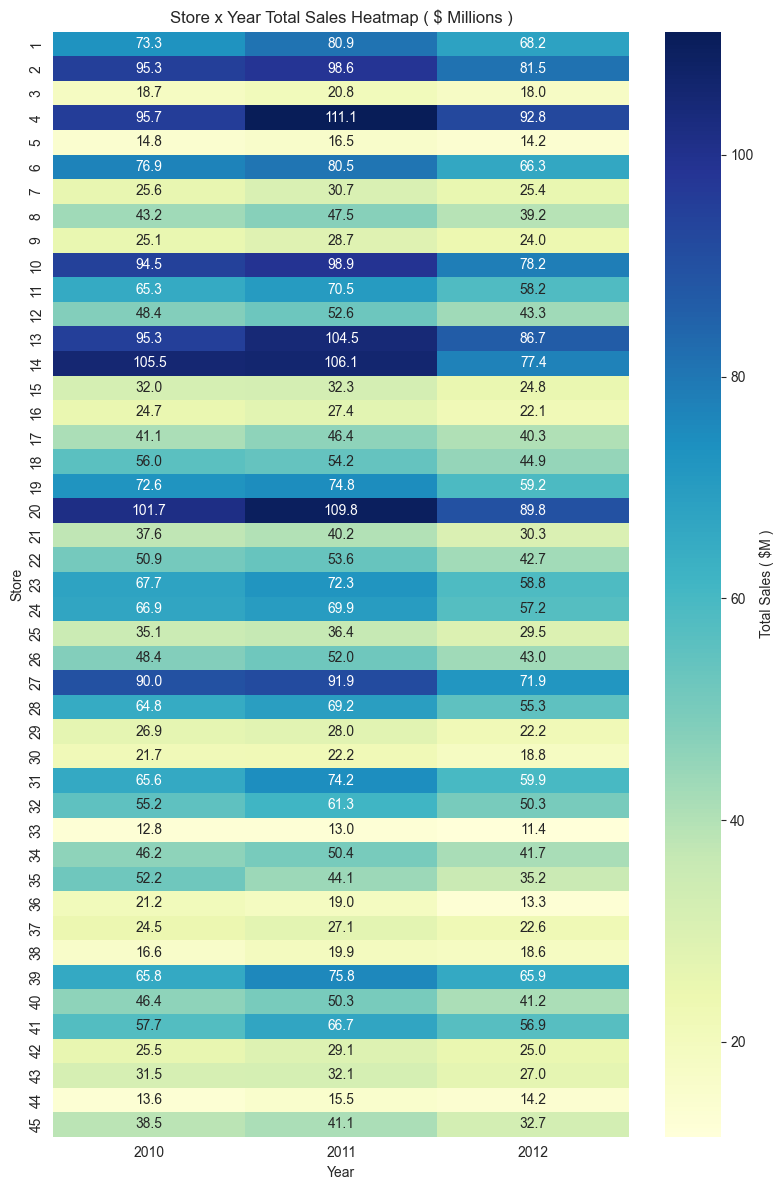

In [9]:
fig, ax = plt.subplots(figsize=(8, 12))
sns.heatmap(pivot[[2010, 2011, 2012]] / 1e6, annot=True, fmt='.1f', cmap='YlGnBu',
            cbar_kws={'label': 'Total Sales ( $M )'}, ax=ax)
ax.set_title('Store x Year Total Sales Heatmap ( $ Millions )')
ax.set_xlabel('Year')
ax.set_ylabel('Store')
plt.tight_layout()
plt.savefig('store_year_heatmap.png', dpi=150)
plt.show()

Unemployment   -0.11
CPI            -0.07
Temperature    -0.06
Fuel_Price      0.01
Name: Weekly_Sales, dtype: float64


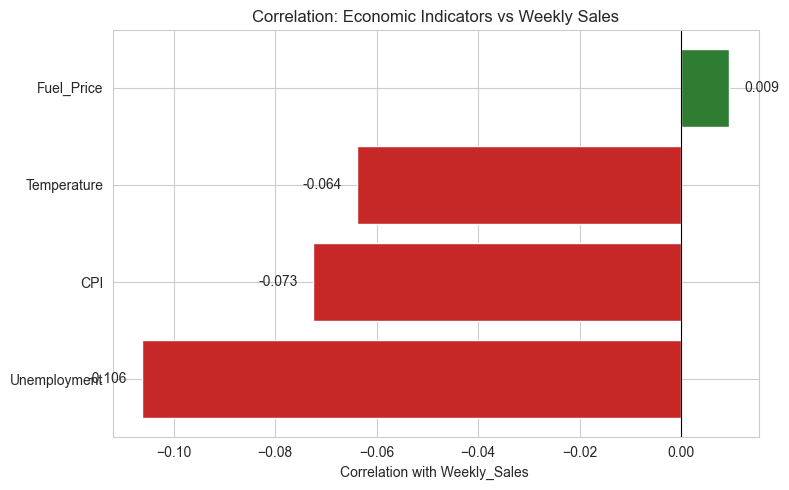

In [10]:
indicators = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
corr = df[['Weekly_Sales'] + indicators].corr()['Weekly_Sales'].drop('Weekly_Sales').sort_values()
print(corr)
fig, ax = plt.subplots(figsize=(8, 5))
colors3 = ['#c62828' if v < 0 else '#2e7d32' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with Weekly_Sales ')
ax.set_title('Correlation: Economic Indicators vs Weekly Sales')
for i, v in enumerate(corr.values):
    ax.text(v + (0.003 if v>=0 else -0.003), i, f'{v:.3f}', va='center', ha='left' if v>=0 else 'right')
plt.tight_layout()
plt.savefig('correlation_indicators.png', dpi=150)
plt.show()

In [11]:
store_unemp_corr = df.groupby('Store').apply(lambda g: g['Weekly_Sales'].corr(g['Unemployment'])).sort_values()
print("Most negatively sensitive to unemployment ( sales fall as unemployment rises ):")
print(store_unemp_corr.head(5))
print("\nLeast sensitive / inversely behaving stores:")
print(store_unemp_corr.tail(5))

Most negatively sensitive to unemployment ( sales fall as unemployment rises ):
Store
38   -0.79
44   -0.78
39   -0.38
42   -0.36
41   -0.35
dtype: float64

Least sensitive / inversely behaving stores:
Store
30   0.20
14   0.21
21   0.22
35   0.48
36   0.83
dtype: float64


In [12]:
vol = df.groupby('Store')['Weekly_Sales'].agg(Mean='mean', Std='std')
vol['CV_%'] = vol['Std'] / vol['Mean'] * 100
print("Most unpredictable ( highest coefficient of variation ):")
print(vol.sort_values('CV_%', ascending=False).head(5))
print("\nMost stable ( lowest CV ):")
print(vol.sort_values('CV_%', ascending=False).tail(5))

Most unpredictable ( highest coefficient of variation ):
              Mean        Std  CV_%
Store                              
35      919,724.98 211,243.46 22.97
7       570,617.31 112,585.47 19.73
15      623,312.47 120,538.65 19.34
29      539,451.43  99,120.14 18.37
23    1,389,864.46 249,788.04 17.97

Most stable ( lowest CV ):
              Mean        Std  CV_%
Store                              
31    1,395,901.44 125,855.94  9.02
44      302,748.87  24,762.83  8.18
43      633,324.72  40,598.41  6.41
30      438,579.62  22,809.67  5.20
37      518,900.28  21,837.46  4.21


In [13]:
hol_2011 = df[(df['Year'] == 2011) & (df['Holiday_Flag'] == 1)].groupby('Store')['Weekly_Sales'].mean()
normal_2011 = df[(df['Year'] == 2011) & (df['Holiday_Flag'] == 0)].groupby('Store')['Weekly_Sales'].mean()
hol_uplift_2011 = (hol_2011 / normal_2011 - 1) * 100
declining = pivot[pivot['YoY_2011_%'] < 0].copy()
declining['Holiday_Uplift_2011_%'] = hol_uplift_2011.loc[declining.index]
flagged = declining[declining['Holiday_Uplift_2011_%'] > 0]
print("Stores with YoY sales decline in 2011 despite positive holiday-week uplift ( flag for investigation ) ")
flagged[[2010, 2011, 'YoY_2011_%', 'Holiday_Uplift_2011_%']]

Stores with YoY sales decline in 2011 despite positive holiday-week uplift ( flag for investigation ) 


Year,2010,2011,YoY_2011_%,Holiday_Uplift_2011_%
Store,,,,
18,"55,978,417.30","54,217,740.11",-3.15,14.12
35,"52,195,970.93","44,086,978.63",-15.54,33.72
